# Is the $r_e$ retrieval effectively an $\omega$ retrieval?

**Question.** The retrieval's $r_e$ signal enters the ToA reflectance through two
channels: the single-scattering albedo $\omega(r_e)$ (absorption) and the phase-function
Legendre coefficients $g_\ell(r_e)$ (scattering shape). By the chain rule,

$$\frac{\partial R}{\partial r_e}
  = \underbrace{\frac{\partial R}{\partial \omega}\frac{\partial \omega}{\partial r_e}}_{J_\omega}
  + \underbrace{\sum_\ell \frac{\partial R}{\partial g_\ell}\frac{\partial g_\ell}{\partial r_e}}_{J_g}.$$

If the $\omega$ channel dominates, the differentiable pipeline can be simplified:
trace full Mie only for $\omega$ (cheap — scalar output, no Legendre projection) and use
Henyey–Greenstein with a table-interpolated $g$ for the phase function. That would
eliminate the $(n_{re}, N_{\rm Leg})$ Legendre table entirely and give an exact AD
Jacobian for the dominant channel.

**Method — freeze-one-channel closures.** We compute, at a shared evaluation state
(the adiabatic prior), three Jacobians by modifying the optics closures fed to
`riccati_solve`:

- $J_{\rm full}$ — both $\omega$ and $g_\ell$ vary with $r_e$ (the production pipeline);
- $J_\omega$ — $\omega$ varies, $g_\ell$ frozen at the evaluation profile;
- $J_g$ — $g_\ell$ varies, $\omega$ frozen at the evaluation profile.

Because both partials are evaluated *at the same state*, the chain rule makes the split
**exactly additive**: $J_{\rm full} = J_\omega + J_g$ (up to solver/float32 tolerance).
We verify both that identity and that $J_{\rm full}$ reproduces the production
`RetrievalForward.jacobian`.

**Regimes** (the thinnest clean vertical penetrations in the VOCALS-REx archive, plus a
thick control): thin A (RF03, $\tau\!\approx\!1.5$), thin B (RF10, $\tau\!\approx\!1.6$,
independent flight), thick (RF03, $\tau\!\approx\!23$). Bands 1.24 and 2.13 µm
(weak vs strong absorption); the 3 view angles of the retrieval notebook. Thin cloud at
1.24 µm is the case most likely to show $g$-sensitivity (single-scatter dominated, weak
absorption); thick cloud at 2.13 µm should be overwhelmingly $\omega$-driven.

This notebook is a **diagnostic**, not a production module — it decides whether the
hybrid (traced-Mie-$\omega$ + HG-$g$) pipeline is worth building
(`docs/OUTSTANDING.md` §B).

In [1]:
%matplotlib inline
import sys
from pathlib import Path
from math import pi

repo_root = Path.cwd().parent
sys.path.insert(0, str(repo_root / 'src'))
sys.path.insert(0, str(repo_root.parent / 'miejax_lite'))  # sibling pkg (if not pip-installed)

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

import vocals_io as vio
import retrieval_oe as roe
from pydisort_riccati_jax import riccati_solve, eval_radiance
from miejax_lite import (
    mie_legendre_precompute, build_re_table, select_channel, table_lookup,
    mie_avg, water_refractive_index,
)

## 1. The three truth profiles

thin A: RF03, tau_bot=1.53, r_e 4.8-6.2 um, n=21
thin B: RF10, tau_bot=1.62, r_e 4.5-6.2 um, n=17
thick: RF03, tau_bot=23.26, r_e 5.5-11.4 um, n=109


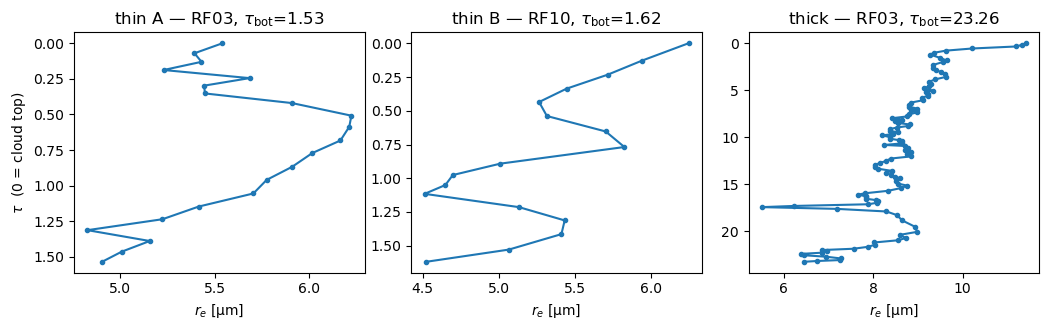

In [2]:
DATA = ('/home/jovyan/cloud_profile_retrieval/'
        'multispectral-retrieval-using-MODIS/VOCALS_REx_data')
profs = vio.load_all_profiles(DATA)
regimes = [
    ('thin A', vio.pick_profile([p for p in profs if p.flight == 'RF03'], 1.53)),
    ('thin B', vio.pick_profile([p for p in profs if p.flight == 'RF10'], 1.62)),
    ('thick',  vio.pick_profile([p for p in profs if p.flight == 'RF03'], 23.3)),
]

fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.4))
for ax, (name, t) in zip(axes, regimes):
    ax.plot(t.r_e, t.tau, 'o-', ms=3)
    ax.invert_yaxis()
    ax.set_xlabel(r'$r_e$ [µm]')
    ax.set_title(f'{name} — {t.flight}, '
                 r'$\tau_{\rm bot}$' f'={t.tau_bot:.2f}')
    print(f'{name}: {t.flight}, tau_bot={t.tau_bot:.2f}, '
          f'r_e {t.r_e.min():.1f}-{t.r_e.max():.1f} um, n={t.tau.size}')
axes[0].set_ylabel(r'$\tau$  (0 = cloud top)')
plt.tight_layout()

## 2. Forward model and the freeze-one-channel closures

Same configuration as `riccati_solver_VOCALS_retrieval.ipynb`: NQuad=16,
`NLeg_all`=128 (the thin-cloud TMS requirement, OUTSTANDING §A′), delta-M + TMS on, dark
ocean BDRF, the standard 32-node $r_e\in[2,25]$ µm optics table. The evaluation state is
the **adiabatic prior on 4 equispaced τ-nodes** — the diagnostic doesn't need the QRCP
grid machinery, and the mode spectrum/Jacobian structure is only weakly state-dependent.
All `NFourier`=8 azimuthal modes are kept (no S$_\varepsilon$ truncation) so the
decomposition is not contaminated by mode-truncation choices.

`forward_partial` is `RetrievalForward._forward_raw` with the 10-line closure
construction modified: the frozen channel's lookup closes over the *reference* node
values (host constants) instead of the traced state, so `jax.jacrev` sees no gradient
path through that channel.

In [3]:
bands = [1.24, 2.13]                        # weak vs strong absorption (µm)
NQuad, NLeg_all, v_eff = 16, 128, 0.10
mu0, I0, phi0 = 0.6, 1.0, 0.0
view_mu = np.array([0.90, 0.65, 0.50])      # ~25, 50, 60 deg view zenith
view_phi = np.array([pi, pi, pi])           # principal plane, back-scatter

precomp = mie_legendre_precompute(max_nstop=512, NLeg=NLeg_all)
table = build_re_table(bands, 2.0, 25.0, 32, v_eff, precomp, n_radii=600)
opt_bands = [select_channel(table, i) for i in range(len(bands))]


def make_forward(truth):
    return roe.RetrievalForward(
        opt_bands, NQuad=NQuad, mu0=mu0, I0=I0, phi0=phi0,
        tau_bot=truth.tau_bot, r_base=truth.r_base,
        view_mu=view_mu, view_phi=view_phi,
        BDRF_bands=[[0.05 / pi]] * len(bands), NLeg_all=NLeg_all)


def forward_partial(fwd, x, tau_nodes, x_ref, freeze):
    """RetrievalForward._forward_raw with one optics channel frozen at x_ref.

    freeze='leg'   -> phase function frozen at x_ref; only omega varies  (-> J_omega)
    freeze='omega' -> omega frozen at x_ref; only the phase function varies (-> J_g)
    freeze=None    -> the unmodified forward (baseline J_full)
    """
    knots, vals = fwd._knots_vals(x, tau_nodes)
    knots_r, vals_r = fwd._knots_vals(np.asarray(x_ref, float), tau_nodes)

    def re_cur(tau):
        return fwd._re_of_tau(tau, knots, vals)

    def re_ref(tau):
        return fwd._re_of_tau(tau, knots_r, vals_r)

    om_src = re_ref if freeze == 'omega' else re_cur
    leg_src = re_ref if freeze == 'leg' else re_cur
    out = []
    for opt, setup, K in zip(fwd.opt_bands, fwd.setups, fwd.K_list):
        def om(tau, opt=opt):
            return table_lookup(opt, om_src(tau))[0]

        def leg(tau, opt=opt):
            return table_lookup(opt, leg_src(tau))[1]

        res = riccati_solve(setup, om, leg, fwd.tau_bot, num_modes=K)
        u = jnp.stack([eval_radiance(setup, res, fwd.view_mu[i], fwd.view_phi[i])
                       for i in range(fwd.n_view)])
        out.append(jnp.pi * u / (fwd.mu0 * fwd.I0))
    return jnp.concatenate(out)


def decompose(fwd, x, tau_nodes):
    """J_full, J_omega, J_g at state x, with the two consistency checks."""
    x = np.asarray(x, float)
    tau_nodes = np.asarray(tau_nodes, float)
    jac = jax.jit(jax.jacrev(
        lambda xx, freeze: forward_partial(fwd, xx, tau_nodes, x, freeze),
        argnums=0), static_argnums=1)
    J_full = np.asarray(jac(jnp.asarray(x), None), float)
    J_om = np.asarray(jac(jnp.asarray(x), 'leg'), float)
    J_g = np.asarray(jac(jnp.asarray(x), 'omega'), float)

    scale = np.abs(J_full).max()
    # (i) the freeze=None path must reproduce the production Jacobian
    J_ref = np.asarray(fwd.jacobian(x, tau_nodes), float)
    err_ref = np.abs(J_full - J_ref).max() / scale
    # (ii) chain-rule additivity at the shared evaluation state
    err_add = np.abs(J_om + J_g - J_full).max() / scale
    print(f'  checks: |J_full - jacobian()| = {err_ref:.1e},  '
          f'|J_om + J_g - J_full| = {err_add:.1e}  (rel. to max|J|)')
    assert err_ref < 1e-4, 'decomposition baseline != production Jacobian'
    assert err_add < 5e-3, 'channel split not additive beyond solver tolerance'
    return J_full, J_om, J_g

## 3. Channel decomposition in the three regimes

In [4]:
results = {}
for name, truth in regimes:
    print(f'--- {name} ({truth.flight}, tau_bot={truth.tau_bot:.2f}) ---')
    fwd = make_forward(truth)
    tau_nodes = np.linspace(0.0, truth.tau_bot, 5)[:-1]
    x, _ = roe.make_adiabatic_prior(tau_nodes, truth.tau_bot, truth.r_base,
                                    r_top_prior=truth.r_top)
    J_full, J_om, J_g = decompose(fwd, x, tau_nodes)
    results[name] = dict(truth=truth, tau_nodes=tau_nodes, x=x,
                         J_full=J_full, J_om=J_om, J_g=J_g)
    jax.clear_caches()      # 3 regimes x 4 jacrev executables: keep memory bounded

--- thin A (RF03, tau_bot=1.53) ---


  checks: |J_full - jacobian()| = 0.0e+00,  |J_om + J_g - J_full| = 2.4e-07  (rel. to max|J|)


--- thin B (RF10, tau_bot=1.62) ---


  checks: |J_full - jacobian()| = 0.0e+00,  |J_om + J_g - J_full| = 1.9e-07  (rel. to max|J|)


--- thick (RF03, tau_bot=23.26) ---


  checks: |J_full - jacobian()| = 0.0e+00,  |J_om + J_g - J_full| = 5.8e-08  (rel. to max|J|)


## 4. Diagnostics: the ω-fraction of the sensitivity

Per observation row (band × view angle), the channel fractions over the state nodes:
$f_\omega = \lVert J_\omega[i,:]\rVert_2 / \lVert J_{\rm full}[i,:]\rVert_2$ and
$f_g$ likewise. (The signed contributions are additive; the fractions can exceed 1 only
if the channels cancel.) The grouped bars below show the **signed per-node**
contributions, the table the row-norm fractions.

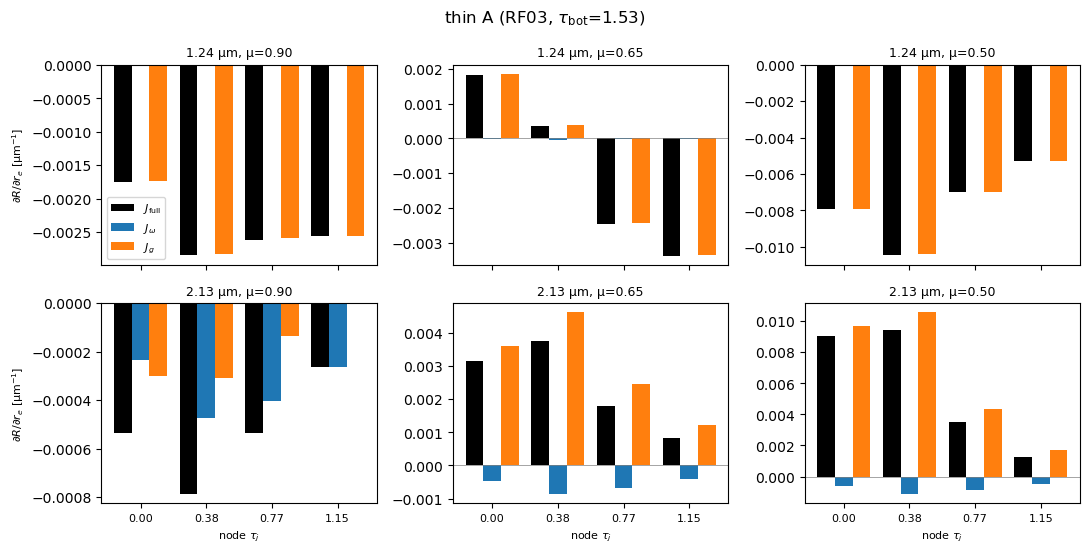

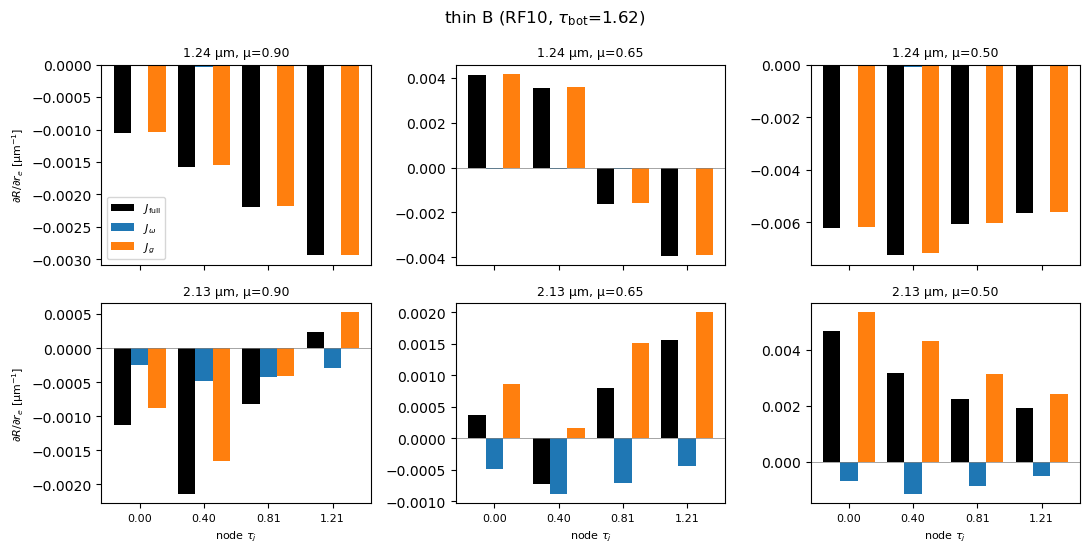

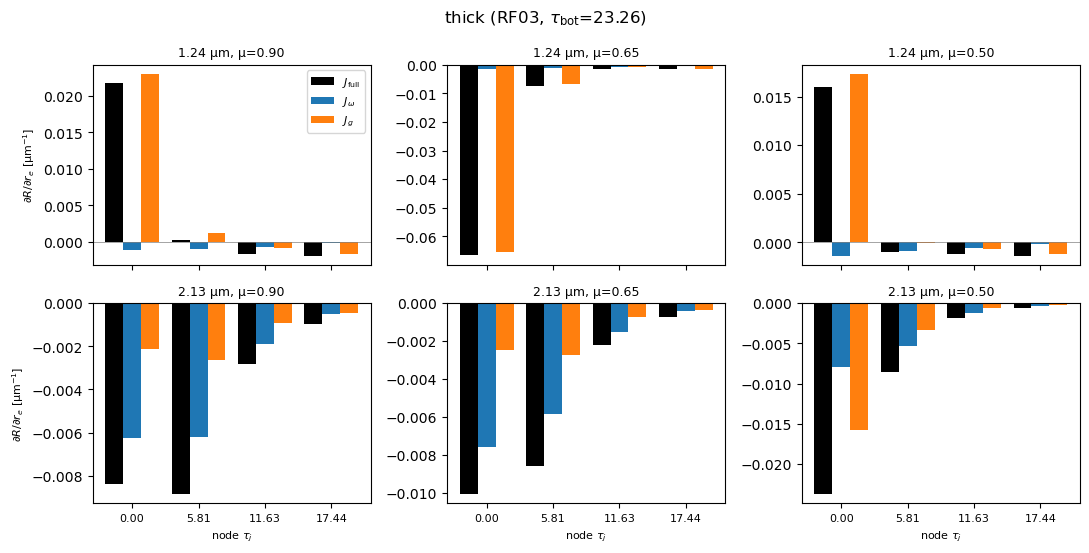

In [5]:
for name, R in results.items():
    truth, tau_nodes = R['truth'], R['tau_nodes']
    J_full, J_om, J_g = R['J_full'], R['J_om'], R['J_g']
    fig, axes = plt.subplots(len(bands), len(view_mu),
                             figsize=(11, 5.6), sharex=True)
    w = 0.27
    jx = np.arange(len(tau_nodes))
    for b in range(len(bands)):
        for v in range(len(view_mu)):
            i = b * len(view_mu) + v
            ax = axes[b, v]
            ax.bar(jx - w, J_full[i], w, label=r'$J_{\rm full}$', color='k')
            ax.bar(jx, J_om[i], w, label=r'$J_\omega$', color='tab:blue')
            ax.bar(jx + w, J_g[i], w, label=r'$J_g$', color='tab:orange')
            ax.axhline(0, color='gray', lw=0.5)
            ax.set_title(f'{bands[b]} µm, µ={view_mu[v]:.2f}', fontsize=9)
            if b == len(bands) - 1:
                ax.set_xticks(jx)
                ax.set_xticklabels([f'{t:.2f}' for t in tau_nodes], fontsize=8)
                ax.set_xlabel(r'node $\tau_j$', fontsize=8)
            if v == 0:
                ax.set_ylabel(r'$\partial R/\partial r_e$ [µm$^{-1}$]', fontsize=8)
    axes[0, 0].legend(fontsize=8)
    fig.suptitle(f'{name} ({truth.flight}, '
                 r'$\tau_{\rm bot}$' f'={truth.tau_bot:.2f})')
    plt.tight_layout()

In [6]:
print(f'{"regime":8s} {"band":>6s}   '
      f'{"omega-fraction (per view mu)":>34s}   {"g-fraction (per view mu)":>30s}')
summary = {}
for name, R in results.items():
    J_full, J_om, J_g = R['J_full'], R['J_om'], R['J_g']
    nf = np.linalg.norm(J_full, axis=1)            # per-row norms
    fo = np.linalg.norm(J_om, axis=1) / nf
    fg = np.linalg.norm(J_g, axis=1) / nf
    for b, band in enumerate(bands):
        sl = slice(b * len(view_mu), (b + 1) * len(view_mu))
        summary[(name, band)] = (fo[sl].mean(), fg[sl].mean())
        print(f'{name:8s} {band:>5.2f}u   '
              + '  '.join(f'{f:>9.3f}' for f in fo[sl]) + '     '
              + '  '.join(f'{f:>8.3f}' for f in fg[sl]))

print()
print('averaged over the three view angles:')
print(f'{"regime":8s} {"band":>6s} {"omega-frac":>11s} {"g-frac":>8s}')
for (name, band), (fo_m, fg_m) in summary.items():
    print(f'{name:8s} {band:>5.2f}u {fo_m:>11.3f} {fg_m:>8.3f}')

regime     band         omega-fraction (per view mu)         g-fraction (per view mu)
thin A    1.24u       0.006      0.012      0.005        0.994     0.996     0.995
thin A    2.13u       0.637      0.239      0.119        0.403     1.227     1.109
thin B    1.24u       0.011      0.012      0.009        0.991     1.005     0.992
thin B    2.13u       0.290      0.677      0.264        0.776     1.370     1.246
thick     1.24u       0.080      0.026      0.109        1.053     0.979     1.081
thick     2.13u       0.722      0.724      0.382        0.280     0.280     0.636

averaged over the three view angles:
regime     band  omega-frac   g-frac
thin A    1.24u       0.008    0.995
thin A    2.13u       0.331    0.913
thin B    1.24u       0.011    0.996
thin B    2.13u       0.410    1.131
thick     1.24u       0.072    1.037
thick     2.13u       0.609    0.399


## 5. Is the table slope a good $\partial\omega/\partial r_e$?

The hybrid pipeline's claimed gain over the current 32-node table is an *exact* (smooth
Mie) $\partial\omega/\partial r_e$ instead of the table's piecewise-constant slope. We
compute $\omega(r_e)$ and $\partial\omega/\partial r_e$ from the table lookup and from
`mie_avg` (the scalar-output gamma-averaged Mie, no Legendre projection — the proposed
traced path) across the full table range.

**Caveat discovered while building this notebook:** `mie_avg`'s radius-integration grid
*moves with* $r_e$ (`linspace(1e-3, 3 r_e, n_radii)`), so at the production
`n_radii=600` the quadrature nodes sweep across the Mie ripple as $r_e$ varies and the
*implemented* $\omega(r_e)$ carries a tiny high-frequency wiggle. AD differentiates the
implementation exactly (it matches a small-h finite difference), so the traced slope
inherits that wiggle — locally up to ~10× the true slope at 2.13 µm. We therefore also
compute a 4×-denser reference at `n_radii=2400` — the slope noise shrinks markedly but, as the figure shows, residual ripple survives even there: the moving-grid artifact converges slowly. The table
slope is judged against the `n_radii=2400` slope (median statistics, robust to the residual ripple), and the n_radii=600 curve shows what a
naively traced Mie-ω path would actually feed the retrieval.

Propagation to the retrieval Jacobian: the $\partial R/\partial\omega$ factor is the
channel-frozen $J_\omega$, identical for table and Mie optics, so
$J_\omega^{\rm mie} \approx \rho_j\, J_\omega^{\rm table}$ with
$\rho_j = (\partial\omega/\partial r_e)_{\rm mie} / (\partial\omega/\partial r_e)_{\rm table}$
at node $j$. If $|\rho - 1|$ is small over the VOCALS $r_e$ range, tracing Mie for ω
buys accuracy that doesn't matter against measurement noise.

1.24 µm over VOCALS r_e range: |table slope/converged - 1| max=1.117 median=0.999;   |traced-600/converged - 1| max=191.386 median=1.347
        max |omega_tab - omega_mie| = 1.01e-04
2.13 µm over VOCALS r_e range: |table slope/converged - 1| max=63.379 median=0.052;   |traced-600/converged - 1| max=79.063 median=0.398
        max |omega_tab - omega_mie| = 9.38e-05


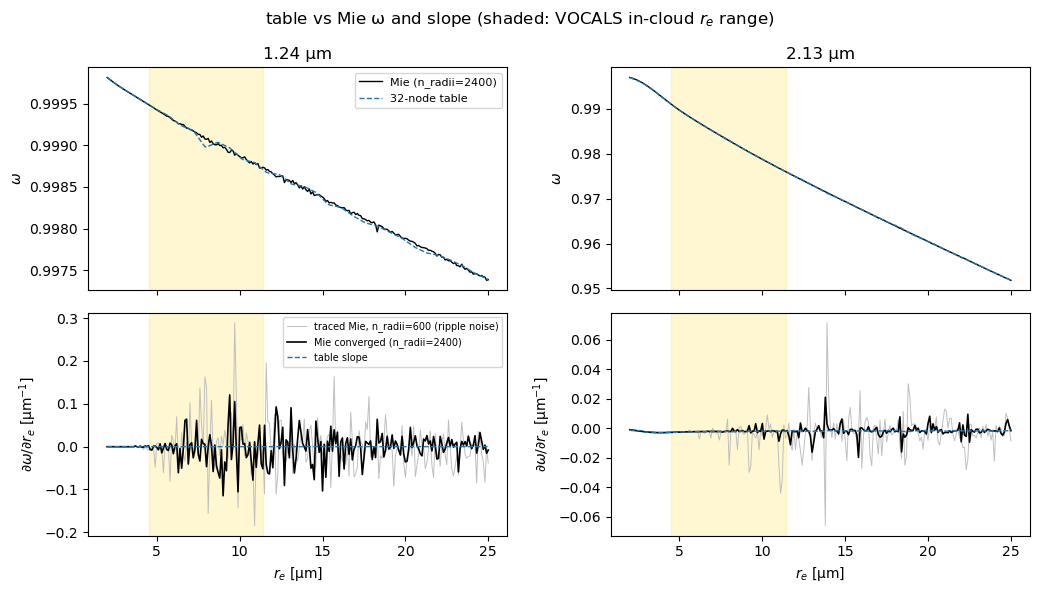

In [7]:
re_dense = jnp.linspace(2.0, 25.0, 231)
N_CONV = 2400                # converged radius quadrature (ripple-free slope)
slope = {}
for band, opt in zip(bands, opt_bands):
    m_re, m_im = water_refractive_index(band)
    om_tab = np.asarray(table_lookup(opt, re_dense)[0])
    s_tab = np.asarray(jax.vmap(jax.grad(
        lambda r: table_lookup(opt, r)[0]))(re_dense))

    def om_mie_f(r, n_radii, band=band, m_re=m_re, m_im=m_im):
        return mie_avg(r, band, v_eff, m_re, m_im,
                       max_nstop=512, n_radii=n_radii)[0]

    S = dict(om_tab=om_tab, s_tab=s_tab,
             grad_tab=jax.jit(jax.grad(
                 lambda r, opt=opt: table_lookup(opt, r)[0])),
             grad_mie=jax.jit(jax.grad(
                 lambda r: om_mie_f(r, N_CONV))))
    for nr, chunk in ((600, 16), (N_CONV, 8)):
        vg = jax.jit(jax.vmap(jax.value_and_grad(
            lambda r, nr=nr: om_mie_f(r, nr))))
        om_mie, s_mie = [], []
        for i in range(0, re_dense.size, chunk):     # chunked: caps peak memory
            o, s = vg(re_dense[i:i + chunk])
            om_mie.append(np.asarray(o))
            s_mie.append(np.asarray(s))
        S[f'om_mie{nr}'] = np.concatenate(om_mie)
        S[f's_mie{nr}'] = np.concatenate(s_mie)
    slope[band] = S

fig, axes = plt.subplots(2, 2, figsize=(10.5, 6), sharex=True)
re_np = np.asarray(re_dense)
vocals_lo = min(R['truth'].r_e.min() for R in results.values())
vocals_hi = max(R['truth'].r_e.max() for R in results.values())
for b, band in enumerate(bands):
    S = slope[band]
    axes[0, b].plot(re_np, S[f'om_mie{N_CONV}'], 'k-', lw=1,
                    label=f'Mie (n_radii={N_CONV})')
    axes[0, b].plot(re_np, S['om_tab'], 'C0--', lw=1, label='32-node table')
    axes[0, b].set_title(f'{band} µm')
    axes[0, b].set_ylabel(r'$\omega$')
    axes[1, b].plot(re_np, S['s_mie600'], color='0.75', lw=0.7,
                    label='traced Mie, n_radii=600 (ripple noise)')
    axes[1, b].plot(re_np, S[f's_mie{N_CONV}'], 'k-', lw=1.2,
                    label=f'Mie converged (n_radii={N_CONV})')
    axes[1, b].plot(re_np, S['s_tab'], 'C0--', lw=1, label='table slope')
    axes[1, b].set_ylabel(r'$\partial\omega/\partial r_e$ [µm$^{-1}$]')
    axes[1, b].set_xlabel(r'$r_e$ [µm]')
    for ax in axes[:, b]:
        ax.axvspan(vocals_lo, vocals_hi, color='gold', alpha=0.18)
axes[0, 0].legend(fontsize=8)
axes[1, 0].legend(fontsize=7)
fig.suptitle('table vs Mie ω and slope (shaded: VOCALS in-cloud $r_e$ range)')
plt.tight_layout()

in_cloud = (re_np >= vocals_lo) & (re_np <= vocals_hi)
for band in bands:
    S = slope[band]
    s_ref = S[f's_mie{N_CONV}']
    rel_tab = np.abs(S['s_tab'] - s_ref) / np.abs(s_ref)
    rel_600 = np.abs(S['s_mie600'] - s_ref) / np.abs(s_ref)
    print(f'{band} µm over VOCALS r_e range: '
          f'|table slope/converged - 1| max={rel_tab[in_cloud].max():.3f} '
          f'median={np.median(rel_tab[in_cloud]):.3f};   '
          f'|traced-600/converged - 1| max={rel_600[in_cloud].max():.3f} '
          f'median={np.median(rel_600[in_cloud]):.3f}')
    print(f'        max |omega_tab - omega_mie| = '
          f'{np.abs(S["om_tab"] - S[f"om_mie{N_CONV}"])[in_cloud].max():.2e}')

In [8]:
# propagate the slope ratio through the omega-channel Jacobian, per regime
print('rho_j = (dω/dr_e)_Mie,converged / (dω/dr_e)_table at the eval nodes;')
print('||J_om^mie - J_om^table|| / ||J_full||  estimates the Jacobian error the')
print('current table slope induces (per regime, per band block).')
print()
for name, R in results.items():
    x = R['x']
    J_om, J_full = R['J_om'], R['J_full']
    line = f'{name:8s}'
    for b, band in enumerate(bands):
        S = slope[band]
        s_t = np.array([float(S['grad_tab'](float(v))) for v in x])
        s_m = np.array([float(S['grad_mie'](float(v))) for v in x])
        rho = s_m / s_t
        sl = slice(b * len(view_mu), (b + 1) * len(view_mu))
        dJ = J_om[sl] * (rho[None, :] - 1.0)
        rel = np.linalg.norm(dJ) / np.linalg.norm(J_full[sl])
        line += (f'   {band:.2f}µm: |rho-1| max={np.abs(rho - 1).max():.3f}, '
                 f'Jac err={rel:.3f}')
    print(line)

rho_j = (dω/dr_e)_Mie,converged / (dω/dr_e)_table at the eval nodes;
||J_om^mie - J_om^table|| / ||J_full||  estimates the Jacobian error the
current table slope induces (per regime, per band block).



thin A     1.24µm: |rho-1| max=22.407, Jac err=0.125   2.13µm: |rho-1| max=0.031, Jac err=0.002


thin B     1.24µm: |rho-1| max=22.054, Jac err=0.158   2.13µm: |rho-1| max=0.035, Jac err=0.007


thick      1.24µm: |rho-1| max=37.682, Jac err=1.019   2.13µm: |rho-1| max=3.000, Jac err=0.271


## 6. Does the phase-function detail change the *retrieval outcome*?

The Jacobian fractions measure sensitivity; the retrieval test measures consequence. Run
the thin-cloud (hardest-case) OE retrieval twice against the **same** observation
(generated with the full Mie table): once with the production Mie-table phase function,
once with HG built from the table asymmetry parameter,
$g_\ell^{\rm HG} = g^\ell$ with $g = \chi_1(r_e)$ from the table. The HG forward has a
phase-function *model error*; if the retrieval is effectively an ω retrieval, the
retrieved profile and posterior should barely move.

Both retrieval forwards are **bounded-state**: the node values are clamped to the
optics-table support $[2, 25]$ µm *inside* the forward map. The HG model error can push
intermediate GN iterates outside the physical range, where the `re5-linear` profile
class takes the 5th root of a negative number → NaN optics → the adaptive Riccati solve
rejects steps until `max_steps` (this happened: unbounded, the HG retrieval crashes).
Clamping is the standard OE bounded-state device; it is the identity (gradient 1) for
in-range states, so the Mie retrieval is unaffected unless its iterates leave the range
too.

In [9]:
RE_LO, RE_HI = 2.0, 25.0                   # optics-table support [µm]


class ClampedForward(roe.RetrievalForward):
    """Bounded-state RetrievalForward: node values clamped to the table support
    inside the forward map (identity for in-range states)."""

    def _knots_vals(self, x, tau_nodes):
        knots, vals = super()._knots_vals(x, tau_nodes)
        return knots, jnp.clip(vals, RE_LO, RE_HI)


class RetrievalForwardHG(ClampedForward):
    """ClampedForward with the table phase function replaced by HG(g_table)."""

    def _band_reflectance(self, opt, setup, K, knots, vals):
        ells = jnp.arange(opt['leg'].shape[-1])

        def om(tau):
            return table_lookup(opt, self._re_of_tau(tau, knots, vals))[0]

        def leg(tau):
            g = table_lookup(opt, self._re_of_tau(tau, knots, vals))[1][1]
            return g ** ells

        res = riccati_solve(setup, om, leg, self.tau_bot, num_modes=K)
        u = jnp.stack([eval_radiance(setup, res, self.view_mu[i], self.view_phi[i])
                       for i in range(self.n_view)])
        return jnp.pi * u / (self.mu0 * self.I0)


jax.clear_caches()
thin = regimes[0][1]                                   # thin A: the hardest case
fwd_mie = ClampedForward(
    opt_bands, NQuad=NQuad, mu0=mu0, I0=I0, phi0=phi0,
    tau_bot=thin.tau_bot, r_base=thin.r_base,
    view_mu=view_mu, view_phi=view_phi,
    BDRF_bands=[[0.05 / pi]] * len(bands), NLeg_all=NLeg_all)
fwd_hg = RetrievalForwardHG(
    opt_bands, NQuad=NQuad, mu0=mu0, I0=I0, phi0=phi0,
    tau_bot=thin.tau_bot, r_base=thin.r_base,
    view_mu=view_mu, view_phi=view_phi,
    BDRF_bands=[[0.05 / pi]] * len(bands), NLeg_all=NLeg_all)

y = roe.osse_observation(fwd_mie, thin.tau, thin.r_e)  # Mie truth = "the measurement"
y_hg_truth = roe.osse_observation(fwd_hg, thin.tau, thin.r_e)
sigma_obs = 0.03 * np.maximum(np.abs(y), 0.02)         # ~3% radiometric + floor
print('forward-model discrepancy HG vs Mie at the truth, in noise units '
      '(|R_HG - R_Mie| / sigma):')
print(np.round(np.abs(y_hg_truth - y).reshape(len(bands), -1)
               / sigma_obs.reshape(len(bands), -1), 2))

forward-model discrepancy HG vs Mie at the truth, in noise units (|R_HG - R_Mie| / sigma):
[[12.25 19.22 19.83]
 [10.42 17.37 18.33]]


In [10]:
tau_grid = np.linspace(0.0, thin.tau_bot, 5)[:-1]      # shared fixed grid
x_a, Sa = roe.make_adiabatic_prior(tau_grid, thin.tau_bot, thin.r_base,
                                   r_top_prior=thin.r_top,
                                   sigma_top=3.0, sigma_base=10.0)
Se = np.diag(sigma_obs ** 2)

res_mie = roe.gauss_newton_oe(fwd_mie, y, tau_grid, x_a, Sa, Se,
                              n_iter=10, lm=1e-2, xtol=2e-3)
post_mie = roe.posterior_diagnostics(res_mie.K, res_mie.Sa, res_mie.Se)
jax.clear_caches()
res_hg = roe.gauss_newton_oe(fwd_hg, y, tau_grid, x_a, Sa, Se,
                             n_iter=10, lm=1e-2, xtol=2e-3)
post_hg = roe.posterior_diagnostics(res_hg.K, res_hg.Sa, res_hg.Se)

truth_at = np.interp(tau_grid, thin.tau, thin.r_e)
print(f'{"":12s}' + ''.join(f'  tau={t:<5.2f}' for t in tau_grid))
print(f'{"truth":12s}' + ''.join(f'  {v:8.2f}' for v in truth_at))
print(f'{"prior x_a":12s}' + ''.join(f'  {v:8.2f}' for v in x_a))
print(f'{"Mie":12s}' + ''.join(f'  {v:8.2f}' for v in res_mie.x))
print(f'{"HG":12s}' + ''.join(f'  {v:8.2f}' for v in res_hg.x))
print(f'{"Mie 1-sigma":12s}' + ''.join(f'  {v:8.2f}' for v in post_mie.error))
print(f'{"HG 1-sigma":12s}' + ''.join(f'  {v:8.2f}' for v in post_hg.error))
print()
print(f'|x_HG - x_Mie| / sigma_post(Mie) = '
      f'{np.round(np.abs(res_hg.x - res_mie.x) / post_mie.error, 2)}')
print(f'DOFS: Mie {post_mie.dofs:.2f}, HG {post_hg.dofs:.2f};  '
      f'||y-F||: Mie {np.linalg.norm(res_mie.y - res_mie.Fx):.2e}, '
      f'HG {np.linalg.norm(res_hg.y - res_hg.Fx):.2e}')

              tau=0.00   tau=0.38   tau=0.77   tau=1.15 
truth             5.54      5.66      6.03      5.41
prior x_a         5.54      5.41      5.26      5.09
Mie               5.50      5.48      6.11      5.66
HG               -6.07    -24.01    -15.09     22.43
Mie 1-sigma       1.63      1.61      1.88      2.02
HG 1-sigma        2.95      4.51      5.58      4.39

|x_HG - x_Mie| / sigma_post(Mie) = [ 7.12 18.35 11.27  8.3 ]
DOFS: Mie 2.62, HG 0.72;  ||y-F||: Mie 8.90e-04, HG 4.01e-01


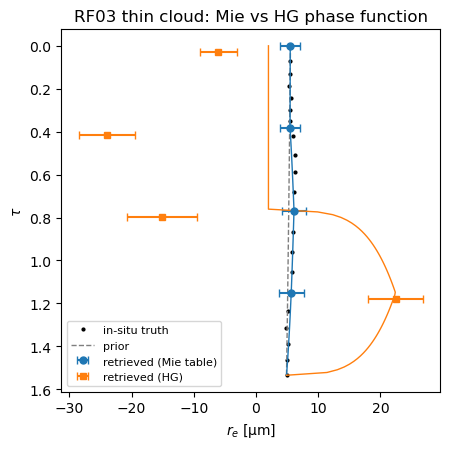

In [11]:
tau_plot = np.linspace(0.0, thin.tau_bot, 120)
fig, ax = plt.subplots(figsize=(4.6, 4.6))
ax.plot(thin.r_e, thin.tau, 'k.', ms=4, label='in-situ truth')
ax.plot(fwd_mie.profile(x_a, tau_grid, tau_plot), tau_plot, 'C7--', lw=1,
        label='prior')
ax.errorbar(res_mie.x, tau_grid, xerr=post_mie.error, fmt='C0o', ms=5,
            capsize=3, label='retrieved (Mie table)')
ax.errorbar(res_hg.x, tau_grid + 0.02 * thin.tau_bot, xerr=post_hg.error,
            fmt='C1s', ms=5, capsize=3, label='retrieved (HG)')
ax.plot(fwd_mie.profile(res_mie.x, tau_grid, tau_plot), tau_plot, 'C0-', lw=1)
ax.plot(fwd_hg.profile(res_hg.x, tau_grid, tau_plot), tau_plot, 'C1-', lw=1)
ax.invert_yaxis()
ax.set_xlabel(r'$r_e$ [µm]')
ax.set_ylabel(r'$\tau$')
ax.set_title(f'{thin.flight} thin cloud: Mie vs HG phase function')
ax.legend(fontsize=8)
plt.tight_layout()

## 7. Conclusions

**No — the $r_e$ retrieval is not effectively an ω retrieval.** The phase-function
channel dominates everywhere except the single most favourable case, and even there it
is far from negligible:

| regime | band | ω-fraction (avg over views) | g-fraction |
|---|---|---|---|
| thin A (τ=1.5) | 1.24 µm | **0.008** | 0.995 |
| thin A | 2.13 µm | 0.33 | 0.91 |
| thin B (τ=1.6) | 1.24 µm | **0.011** | 1.00 |
| thin B | 2.13 µm | 0.41 | 1.13 |
| thick (τ=23) | 1.24 µm | **0.07** | 1.04 |
| thick | 2.13 µm | 0.61 | 0.40 |

(Fractions are row-norm ratios; they can exceed 1 when the signed channels partially
cancel. The split is verified: the freeze-`None` baseline reproduces
`RetrievalForward.jacobian` exactly, and $J_\omega + J_g = J_{\rm full}$ holds to
~2×10⁻⁷ relative.)

**The proposed hybrid pipeline (trace Mie for ω, HG for the phase function, drop the
Legendre table) is rejected**, on three independent grounds:

1. **The dominant channel would be the approximated one.** For thin clouds —
   the regime the τ-varying solver exists for — ~99% (1.24 µm) and ~60–90% (2.13 µm) of
   the $r_e$ sensitivity flows through the phase-function shape, not absorption.
2. **HG is not a small phase-function error.** At the truth profile the HG forward is
   10–20σ from the Mie forward (3% radiometric noise). The §6 retrieval is not merely
   biased — it is *broken*: no state fits the observation (‖y−F‖ = 4×10⁻¹ vs 9×10⁻⁴ for
   Mie), GN pegs the nodes at the state bounds 7–18 posterior σ away from the Mie
   solution, and DOFS collapses from 2.6 to 0.7. (Unbounded, the very first GN step
   overshoots to $r_e < 0$ and NaNs the solve — hence the bounded-state forward.)
   The Mie-table retrieval recovers the in-situ truth to ~0.3 µm.
3. **The "exact AD Jacobian" motivation fails on its own terms.** AD through `mie_avg`
   at the production `n_radii=600` differentiates radius-quadrature ripple (the radius
   grid `linspace(1e-3, 3 r_e, n)` moves with $r_e$, sweeping nodes across the Mie
   resonances): the traced slope is locally up to ~10× the true slope (median error
   ~40–130% over the VOCALS range), while ω itself is reproduced to ~10⁻⁴. Judged
   against a 4×-denser (`n_radii=2400`) reference — itself still visibly rippled, so
   medians are the meaningful statistic and the smooth 32-node table slope is arguably
   the *best* derivative estimate available — the **table slope agrees to ~5% (median)
   at 2.13 µm**, and its propagated ω-channel Jacobian error in the thin
   regimes is 0.2–0.7% of ‖J_full‖ — far below noise. (At 1.24 µm both slopes are near
   zero — relative ratios there are ill-conditioned and meaningless, and the ω channel
   is irrelevant anyway. The thick/2.13 block shows ~27% propagated table-slope error;
   if that ever matters, the fix is a denser $r_e$ table, not traced Mie.)

**Practical upshots.**

- Keep the $(n_{re}, N_{\rm Leg})$ Legendre table as the production optics path — the
  OUTSTANDING §B decision is strengthened, not revisited. Phase-function fidelity is a
  first-order requirement of the $r_e$ retrieval at all τ probed here.
- If a traced-Mie ω path is ever wanted (e.g. hyperspectral ω(λ) work), `mie_avg` needs
  an $r_e$-independent radius grid (or `n_radii` ≳ 2400) before its gradient is usable.
- The GN state must be bounded to the optics-table support inside the forward map
  (`ClampedForward`); large *model* error (not just bad priors) can otherwise drive
  iterates into NaN territory.
